# 📊 PIPELINE DATA SCIENCE - DASHBOARD DATASET

## Urutan Lengkap & Terstruktur:
1. **Data Collection** - Load data dari CSV
2. **Data Wrangling**
   - 2a. Cleaning - Pembersihan & Normalisasi
   - 2b. Transformation - Feature Engineering
   - 2c. Integration - Merge dengan Benchmark
3. **Data Validation** - Quality Checks
4. **EDA (Exploratory Data Analysis)** - Analisis & Visualisasi
5. **Feature Selection** - Seleksi Kolom Penting
6. **Final Output** - Export Data Bersih

---

# ⚙️ SEL 1: INISIALISASI LINGKUNGAN & LOAD LIBRARIES

### 🎯 Fungsi Utama
Memuat seluruh pustaka (*libraries*) yang diperlukan untuk:
- Manipulasi data (pandas, numpy)
- Pemrosesan teks (regex)
- Pengolahan waktu (datetime)
- Visualisasi (matplotlib, seaborn)
- Statistik & analisis (scipy, sklearn)

### ⚙️ Konfigurasi:
- **Random Seed (42)**: Memastikan reproducibility di setiap komputer
- **Display Options**: Konfigurasi tampilan pandas untuk readability
- **Warning Suppression**: Menyembunyikan warning yang tidak penting

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from difflib import get_close_matches
import re
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Konfigurasi
np.random.seed(42)
warnings.filterwarnings('ignore')

# Display options untuk pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Style untuk matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Semua library berhasil dimuat!")
print(f"✅ Random Seed: 42 (Reproducible)")
print(f"✅ Session dimulai: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Semua library berhasil dimuat!
✅ Random Seed: 42 (Reproducible)
✅ Session dimulai: 2026-06-05 11:07:28


# 📥 SEL 2: DATA COLLECTION - LOAD DATA DARI CSV

### 🎯 Fungsi Utama
Memuat dua dataset utama:
1. **Dataset Transaksi** (`master_dashboard_data.csv`) - Data transaksi pengguna
2. **Dataset Benchmark** (`market_benchmark_cleaned.csv`) - Kamus harga acuan pasar

### ⚙️ Mekanisme Keamanan:
- **Dynamic Path Resolution**: Menggunakan `pathlib.Path()` agar portable
- **Exception Handling**: Menangkap error dengan graceful
- **UTF-8 Encoding**: Aman untuk karakter Indonesia

In [3]:
# ============================================================================
# STEP 1: Define file paths dynamically
# ============================================================================

base_dir = Path('.').resolve()
# Updated filenames as requested
path_dashboard = base_dir / 'public_transactions_test_fixed.csv'
path_benchmark = base_dir / 'market_benchmark_cleaned.csv'

print(f"📂 Base Directory: {base_dir}")
print(f"📂 Transaction Path: {path_dashboard}")
print(f"📂 Benchmark Path: {path_benchmark}\n")

# ============================================================================
# STEP 2: Load data with robust exception handling
# ============================================================================

try:
    if not path_dashboard.exists() or not path_benchmark.exists():
        raise FileNotFoundError("Target CSV files not found in the current directory.")
        
    df_transactions = pd.read_csv(path_dashboard, encoding='utf-8-sig', engine='python')
    df_benchmark = pd.read_csv(path_benchmark, encoding='utf-8-sig', engine='python')
    
    print("✅ Data successfully loaded!")
    print(f"   ├─ Transactions: {len(df_transactions)} rows, {len(df_transactions.columns)} columns")
    print(f"   └─ Benchmark: {len(df_benchmark)} rows, {len(df_benchmark.columns)} columns\n")
    
except Exception as e:
    print(f"❌ ERROR: {e}")

📂 Base Directory: G:\Semester4\capstone-project
📂 Transaction Path: G:\Semester4\capstone-project\public_transactions_test_fixed.csv
📂 Benchmark Path: G:\Semester4\capstone-project\market_benchmark_cleaned.csv

✅ Data successfully loaded!
   ├─ Transactions: 1220 rows, 4 columns
   └─ Benchmark: 305 rows, 6 columns



# 🔍 SEL 3: DATA INSPECTION - PEMERIKSAAN AWAL DATA

### 🎯 Fungsi Utama
Memahami struktur & karakteristik data sebelum processing:
- Shape, dtype, columns
- Sample data
- Missing values
- Basic statistics

In [4]:
print("="*80)
print("📋 INSPECTION: DATASET TRANSAKSI")
print("="*80)
print(f"\n📊 Shape: {df_transactions.shape}")
print(f"\n🔑 Columns: {list(df_transactions.columns)}")
print(f"\n📈 Data Types:")
print(df_transactions.dtypes)
print(f"\n📋 Sample Data (5 baris pertama):")
display(df_transactions.head())
print(f"\n❓ Missing Values:")
missing_trans = df_transactions.isnull().sum()
print(missing_trans[missing_trans > 0] if missing_trans.sum() > 0 else "✅ Tidak ada missing values")

print("\n" + "="*80)
print("📋 INSPECTION: DATASET BENCHMARK")
print("="*80)
print(f"\n📊 Shape: {df_benchmark.shape}")
print(f"\n🔑 Columns: {list(df_benchmark.columns)}")
print(f"\n📈 Data Types:")
print(df_benchmark.dtypes)
print(f"\n📋 Sample Data (5 baris pertama):")
display(df_benchmark.head())
print(f"\n❓ Missing Values:")
missing_bench = df_benchmark.isnull().sum()
print(missing_bench[missing_bench > 0] if missing_bench.sum() > 0 else "✅ Tidak ada missing values")

📋 INSPECTION: DATASET TRANSAKSI

📊 Shape: (1220, 4)

🔑 Columns: ['transaction_name', 'amount', 'category', 'category_encoded']

📈 Data Types:
transaction_name        str
amount              float64
category                str
category_encoded      int64
dtype: object

📋 Sample Data (5 baris pertama):


,transaction_name,amount,category,category_encoded
0,TIKET BIOSKOP XXI - <ID>,284160.0,Hiburan,1
1,DRV SPOTIFY*PREMIUM - <ID>,308000.0,Hiburan,1
2,NETFLIX*SUBSCRIPTION - <ID>,139860.0,Hiburan,1
3,TAGIHAN AIR PDAM - <ID>,230250.0,Tagihan,3
4,PEMBAYARAN LISTRIK PLN - <ID>,498390.0,Tagihan,3



❓ Missing Values:
✅ Tidak ada missing values

📋 INSPECTION: DATASET BENCHMARK

📊 Shape: (305, 6)

🔑 Columns: ['item_category', 'item_name', 'avg_price', 'lower_bound', 'upper_bound', 'price_margin']

📈 Data Types:
item_category        str
item_name            str
avg_price        float64
lower_bound        int64
upper_bound        int64
price_margin       int64
dtype: object

📋 Sample Data (5 baris pertama):


,item_category,item_name,avg_price,lower_bound,upper_bound,price_margin
0,Belanja,Baju Kaos Polos Katun,45000.0,30000,85000,55000
1,Belanja,Baterai Aa Alkaline 4Pcs,20000.0,15000,30000,15000
2,Belanja,Baterai Aa Remote/Mouse,15000.0,10000,25000,15000
3,Belanja,Beli Buku Pemrograman Python/Sql,85000.0,50000,150000,100000
4,Belanja,Beras Premium 5Kg,75000.0,60000,90000,30000



❓ Missing Values:
✅ Tidak ada missing values


# 🧹 SEL 4: DATA CLEANING - PEMBERSIHAN & NORMALISASI

### 🎯 Fungsi Utama
Tahap **Data Wrangling 2a (Cleaning)**:
- Hapus duplikat
- Normalisasi teks (lowercase, remove noise)
- Handle missing values
- Standardisasi format

### ⚙️ Metode:
1. **Regex Noise Stripping**: Hapus ID dan noise dari transaction names
2. **Case Normalization**: Semua lowercase untuk consistency
3. **Deduplication**: Hapus duplikat baris
4. **Type Conversion**: Pastikan tipe data benar

In [5]:
print("="*80)
print("🧹 TAHAP 1: CLEANING - DATASET TRANSAKSI")
print("="*80)

# Create working copy
df = df_transactions.copy()

print(f"\n📌 Data awal: {len(df)} baris")

# 1. Remove duplicates
print(f"\n1️⃣  Menghapus duplikat...")
duplicates_before = len(df)
df = df.drop_duplicates()
duplicates_removed = duplicates_before - len(df)
print(f"   ✅ Duplikat dihapus: {duplicates_removed} baris")
print(f"   📊 Sisa data: {len(df)} baris")

# 2. Clean transaction names
print(f"\n2️⃣  Membersihkan nama transaksi...")
# Pattern: Hapus ' - <ID>...' dan '*MEMO/*PROMO' dll
df['clean_name'] = df['transaction_name'].apply(
    lambda x: re.sub(
        r'\s*-\s*<ID>.*|\*MEMO|\*PROMO|\*.*',  # Pattern to remove
        '',
        str(x),
        flags=re.IGNORECASE
    ).strip().lower()  # lowercase & remove leading/trailing spaces
)

print(f"   ✅ Normalisasi teks selesai")
print(f"   📋 Contoh sebelum & sesudah:")
sample_clean = df[['transaction_name', 'clean_name']].head(5)
display(sample_clean)

# 3. Handle missing values
print(f"\n3️⃣  Menangani missing values...")
missing_cols = df.isnull().sum()
if missing_cols.sum() > 0:
    print(f"   ⚠️  Ditemukan missing values:")
    for col, count in missing_cols[missing_cols > 0].items():
        print(f"      - {col}: {count} rows")
    
    # Fill missing dengan strategi yang tepat
    if 'amount' in df.columns:
        df['amount'].fillna(df['amount'].median(), inplace=True)
        print(f"   ✅ Amount: Filled dengan median")
    
    if 'transaction_date' in df.columns:
        df['transaction_date'].fillna(df['transaction_date'].mode()[0], inplace=True)
        print(f"   ✅ Date: Filled dengan mode")
else:
    print(f"   ✅ Tidak ada missing values")

# 4. Data type conversion
print(f"\n4️⃣  Standardisasi tipe data...")
if 'amount' in df.columns:
    df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
    print(f"   ✅ amount -> numeric")

if 'transaction_date' in df.columns:
    df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
    print(f"   ✅ transaction_date -> datetime")

print(f"\n📊 Data setelah cleaning: {len(df)} baris, {len(df.columns)} kolom")

# 5. Cleaning untuk Benchmark
print(f"\n" + "="*80)
print(f"🧹 TAHAP 1b: CLEANING - DATASET BENCHMARK")
print(f"="*80)

df_bench = df_benchmark.copy()
print(f"\n📌 Data awal: {len(df_bench)} baris")

# Remove duplicates berdasarkan item_name
df_bench = df_bench.drop_duplicates(subset=['item_name'])
print(f"✅ Data setelah dedup: {len(df_bench)} baris")

# Normalize item names
if 'item_name' in df_bench.columns:
    df_bench['item_name'] = df_bench['item_name'].apply(
        lambda x: str(x).strip().lower()
    )
    print(f"✅ Item names normalized")

print(f"\n📊 Benchmark setelah cleaning: {len(df_bench)} baris")

🧹 TAHAP 1: CLEANING - DATASET TRANSAKSI

📌 Data awal: 1220 baris

1️⃣  Menghapus duplikat...
   ✅ Duplikat dihapus: 19 baris
   📊 Sisa data: 1201 baris

2️⃣  Membersihkan nama transaksi...
   ✅ Normalisasi teks selesai
   📋 Contoh sebelum & sesudah:


,transaction_name,clean_name
0,TIKET BIOSKOP XXI - <ID>,tiket bioskop xxi
1,DRV SPOTIFY*PREMIUM - <ID>,drv spotify
2,NETFLIX*SUBSCRIPTION - <ID>,netflix
3,TAGIHAN AIR PDAM - <ID>,tagihan air pdam
4,PEMBAYARAN LISTRIK PLN - <ID>,pembayaran listrik pln



3️⃣  Menangani missing values...
   ✅ Tidak ada missing values

4️⃣  Standardisasi tipe data...
   ✅ amount -> numeric

📊 Data setelah cleaning: 1201 baris, 5 kolom

🧹 TAHAP 1b: CLEANING - DATASET BENCHMARK

📌 Data awal: 305 baris
✅ Data setelah dedup: 304 baris
✅ Item names normalized

📊 Benchmark setelah cleaning: 304 baris


# 🔄 SEL 5: DATA TRANSFORMATION - FEATURE ENGINEERING

### 🎯 Fungsi Utama
Tahap **Data Wrangling 2b (Transformation)**:
- Tambah temporal features (year, month, day, dow)
- Extract features dari existing columns
- Aggregations & calculations

### ⚙️ Features yang ditambah:
1. **Datetime Features**: year, month, day, week, day_of_week
2. **Amount Features**: amount_category, amount_quantile
3. **Temporal Patterns**: is_weekend, is_month_end

In [6]:
print("="*80)
print("🔄 TAHAP 2: TRANSFORMATION - FEATURE ENGINEERING")
print("="*80)

# ---------------------------------------------------------
# SYNTHETIC DATE GENERATION
# ---------------------------------------------------------
# If the date column is missing, generate a random timestamp 
# for each row within a specified datetime range.
if 'transaction_date' not in df.columns:
    print(f"\n⚙️ Column 'transaction_date' not found. Generating synthetic dates...")
    start_date = pd.to_datetime('2026-01-01').timestamp()
    end_date = pd.to_datetime('2026-06-05').timestamp()
    
    # Generate array of random timestamps
    random_timestamps = np.random.randint(start_date, end_date, size=len(df))
    df['transaction_date'] = pd.to_datetime(random_timestamps, unit='s')
    print(f"   ✅ Successfully generated {len(df)} random dates.")

# Ensure dtype is datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

print(f"\n1️⃣ Menambah Temporal Features...")

# Extract datetime components
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day'] = df['transaction_date'].dt.day
df['week'] = df['transaction_date'].dt.isocalendar().week
df['day_of_week'] = df['transaction_date'].dt.day_name()
df['is_weekend'] = df['transaction_date'].dt.day_name().isin(['Saturday', 'Sunday']).astype(int)

# Map month integer to string name
month_names = {i: datetime(2000, i, 1).strftime('%B') for i in range(1, 13)}
df['month_name'] = df['month'].map(month_names)

# Year-Month for grouping
df['year_month'] = df['transaction_date'].dt.to_period('M')

print(f"\n2️⃣ Menambah Amount Features...")

# Calculate amount quartiles and categories safely
if len(df['amount'].unique()) > 4: # Ensure enough unique bins exist
    df['amount_quartile'] = pd.qcut(df['amount'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')

def categorize_amount(x):
    if x < 50000: return 'Kecil (<50K)'
    elif x < 100000: return 'Sedang (50-100K)'
    elif x < 500000: return 'Besar (100K-500K)'
    return 'Sangat Besar (>500K)'

df['amount_category'] = df['amount'].apply(categorize_amount)

# Calculate daily deviation
daily_avg = df.groupby(df['transaction_date'].dt.date)['amount'].transform('mean')
df['deviation_from_daily_avg'] = df['amount'] - daily_avg

print(f"\n📊 Fitur berhasil ditambahkan. Total kolom: {len(df.columns)}")

🔄 TAHAP 2: TRANSFORMATION - FEATURE ENGINEERING

⚙️ Column 'transaction_date' not found. Generating synthetic dates...
   ✅ Successfully generated 1201 random dates.

1️⃣ Menambah Temporal Features...

2️⃣ Menambah Amount Features...

📊 Fitur berhasil ditambahkan. Total kolom: 17


# 🔗 SEL 6: DATA INTEGRATION - MERGE DENGAN BENCHMARK

### 🎯 Fungsi Utama
Tahap **Data Wrangling 2c (Integration)**:
- Fuzzy matching antara transaction_name dengan benchmark
- Merge dua dataset
- Enrich transaction data dengan benchmark information

### ⚙️ Strategi Matching:
1. **Exact Match**: Jika clean_name ada di benchmark
2. **Fuzzy Match**: Jika tidak, gunakan string similarity
3. **Fallback**: Jika tidak ada match, mark sebagai 'Unknown'

In [7]:
print("="*80)
print("🔗 TAHAP 3: INTEGRATION & IMPUTATION")
print("="*80)

# 1. PEMBERSIHAN NAMA
def clean_text_noise(text):
    if not isinstance(text, str): return ""
    text = text.upper()
    noise_patterns = [r'\s*-\s*<ID>', r'\*MEMO', r'\*SUBSCRIPTION', r'\*PREMIUM', 
                      r'CAFE', r'SUBSCR1PT10N', r'DRV', r'G0-F00D']
    for pattern in noise_patterns:
        text = re.sub(pattern, '', text)
    return text.strip()

df['clean_name'] = df['transaction_name'].apply(clean_text_noise)
benchmark_items_list = df_bench['item_name'].apply(lambda x: str(x).upper()).tolist()

# 2. FUZZY MATCHING
def fuzzy_match_with_benchmark(clean_name, benchmark_df, benchmark_items, cutoff=0.4):
    if pd.isna(clean_name) or clean_name == "": return None
    matches = get_close_matches(clean_name, benchmark_items, n=1, cutoff=cutoff)
    if matches:
        matched_item = matches[0]
        row = benchmark_df[benchmark_df['item_name'].str.upper() == matched_item].iloc[0]
        return {'matched_item': row['item_name'], 'category': row['item_category'], 
                'avg_price': row['avg_price'], 'lower_bound': row['lower_bound'], 
                'upper_bound': row['upper_bound'], 'match_confidence': 'Matched'}
    return None

matched_data = df['clean_name'].apply(lambda x: fuzzy_match_with_benchmark(x, df_bench, benchmark_items_list))
matched_df = pd.DataFrame([x if x is not None else {
    'matched_item': 'Unknown', 'category': 'Unknown', 'avg_price': 0.0, 
    'lower_bound': 0.0, 'upper_bound': 0.0, 'match_confidence': 'Unknown'
} for x in matched_data.tolist()])

cols_to_drop = ['matched_item', 'category', 'avg_price', 'lower_bound', 'upper_bound', 'match_confidence']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
df = pd.concat([df.reset_index(drop=True), matched_df], axis=1)

# 3. IMPUTASI AMAN (Dengan Safety Check)
unknown_mask = df['match_confidence'] == 'Unknown'
n_unknowns = unknown_mask.sum()

if n_unknowns > 0:
    print(f"⚙️ Melakukan Imputasi pada {n_unknowns} data yang tidak ter-match...")
    
    # Ambil kategori yang HANYA memiliki data di benchmark
    valid_categories = df_bench['item_category'].dropna().unique()
    
    for idx in df[unknown_mask].index:
        random_cat = np.random.choice(valid_categories)
        cat_data_pool = df_bench[df_bench['item_category'] == random_cat]
        
        # Safety Check: Pastikan pool tidak kosong sebelum sample
        if not cat_data_pool.empty:
            cat_data = cat_data_pool.sample(n=1).iloc[0]
            df.at[idx, 'category'] = random_cat
            df.at[idx, 'matched_item'] = cat_data['item_name']
            df.at[idx, 'avg_price'] = cat_data['avg_price']
            df.at[idx, 'lower_bound'] = cat_data['lower_bound']
            df.at[idx, 'upper_bound'] = cat_data['upper_bound']
            df.at[idx, 'match_confidence'] = 'Imputed'
    print("✅ Semua data telah terisi.")

# 4. PRICE STATUS
def calculate_price_status(row):
    if pd.isna(row['avg_price']) or row['avg_price'] == 0: return 'Unknown'
    category = row.get('category', 'Unknown')
    multipliers = {'Hiburan': 2.5, 'Transportasi': 2.0, 'Makanan & Minuman': 2.0}
    multiplier = multipliers.get(category, 1.5)
    
    if row['amount'] > (row['upper_bound'] * multiplier): return 'Extreme'
    elif row['amount'] < row['avg_price']: return 'Cheap'
    return 'Normal'

df['price_status'] = df.apply(calculate_price_status, axis=1)
print(f"\n📊 Distribusi Finansial:")
for status, count in df['price_status'].value_counts().items():
    print(f"   - {status}: {count}")

🔗 TAHAP 3: INTEGRATION & IMPUTATION
⚙️ Melakukan Imputasi pada 21 data yang tidak ter-match...
✅ Semua data telah terisi.

📊 Distribusi Finansial:
   - Normal: 525
   - Extreme: 453
   - Cheap: 223


# ✅ SEL 7: DATA VALIDATION - QUALITY CHECKS

### 🎯 Fungsi Utama
Memastikan data quality setelah processing:
- Check missing values
- Check data types
- Check value ranges
- Check inconsistencies
- Generate quality report

In [8]:
print("="*80)
print("✅ TAHAP 4: DATA VALIDATION - QUALITY CHECKS")
print("="*80)

print(f"\n1️⃣  Checking Missing Values...")
missing_summary = df.isnull().sum()
missing_pct = (missing_summary / len(df)) * 100

critical_cols = ['transaction_date', 'amount', 'clean_name']
has_issues = False

for col in df.columns:
    if missing_summary[col] > 0:
        pct = missing_pct[col]
        if col in critical_cols:
            status = "⚠️  CRITICAL"
            has_issues = True
        else:
            status = "⚠️  WARNING"
        print(f"   {status}: {col} -> {missing_summary[col]} missing ({pct:.2f}%)")

if not has_issues:
    print(f"   ✅ No critical missing values found")

print(f"\n2️⃣  Checking Data Types...")
type_issues = []

# Check numeric columns
numeric_cols = ['amount', 'avg_price', 'lower_bound', 'upper_bound']
for col in numeric_cols:
    if col in df.columns:
        non_numeric = df[col].apply(lambda x: not isinstance(x, (int, float)) if pd.notna(x) else False).sum()
        if non_numeric > 0:
            print(f"   ⚠️  {col}: {non_numeric} non-numeric values")
            type_issues.append(col)
        else:
            print(f"   ✅ {col}: All numeric")

# Check datetime columns
date_cols = ['transaction_date']
for col in date_cols:
    if col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            print(f"   ✅ {col}: Valid datetime")
        else:
            print(f"   ⚠️  {col}: Not datetime type")
            type_issues.append(col)

print(f"\n3️⃣  Checking Value Ranges...")

# Amount should be positive
negative_amounts = (df['amount'] < 0).sum()
if negative_amounts > 0:
    print(f"   ⚠️  amount: {negative_amounts} negative values")
else:
    print(f"   ✅ amount: All positive")

# Amount should be reasonable
zero_amounts = (df['amount'] == 0).sum()
if zero_amounts > 0:
    print(f"   ⚠️  amount: {zero_amounts} zero values")
else:
    print(f"   ✅ amount: No zero values")

# Date range check
if 'transaction_date' in df.columns:
    min_date = df['transaction_date'].min()
    max_date = df['transaction_date'].max()
    date_range = (max_date - min_date).days
    print(f"   ✅ Date range: {min_date.date()} to {max_date.date()} ({date_range} days)")

print(f"\n4️⃣  Checking Data Consistency...")

# Check if amount matches price ranges
out_of_range = 0
for idx, row in df.iterrows():
    if pd.notna(row['lower_bound']) and pd.notna(row['upper_bound']):
        if not (row['lower_bound'] <= row['amount'] <= row['upper_bound'] * 2.5):
            out_of_range += 1

if out_of_range > 0:
    print(f"   ⚠️  {out_of_range} transactions out of typical range")
else:
    print(f"   ✅ All transactions within reasonable range")

print(f"\n5️⃣  Data Quality Report:")
print(f"   ├─ Total records: {len(df)}")
print(f"   ├─ Total columns: {len(df.columns)}")
print(f"   ├─ Matched items: {(df['match_confidence'] == 'High').sum()}")
print(f"   ├─ Unmatched items: {(df['match_confidence'] == 'No Match').sum()}")
print(f"   ├─ Data completeness: {(100 - (df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100)):.2f}%")
print(f"   └─ Status: ✅ READY FOR EDA" if not has_issues else "   └─ Status: ⚠️  REVIEW REQUIRED")

✅ TAHAP 4: DATA VALIDATION - QUALITY CHECKS

1️⃣  Checking Missing Values...
   ✅ No critical missing values found

2️⃣  Checking Data Types...
   ✅ amount: All numeric
   ✅ avg_price: All numeric
   ✅ lower_bound: All numeric
   ✅ upper_bound: All numeric
   ✅ transaction_date: Valid datetime

3️⃣  Checking Value Ranges...
   ✅ amount: All positive
   ✅ amount: No zero values
   ✅ Date range: 2026-01-01 to 2026-06-04 (154 days)

4️⃣  Checking Data Consistency...
   ⚠️  422 transactions out of typical range

5️⃣  Data Quality Report:
   ├─ Total records: 1201
   ├─ Total columns: 23
   ├─ Matched items: 0
   ├─ Unmatched items: 0
   ├─ Data completeness: 100.00%
   └─ Status: ✅ READY FOR EDA


# 📊 SEL 8: EDA (EXPLORATORY DATA ANALYSIS) - ANALISIS DATA

### 🎯 Fungsi Utama
Memahami pattern, trend, dan karakteristik data:
- Descriptive statistics
- Distribution analysis
- Outlier detection
- Correlation analysis
- Trend analysis
- Visualization

In [9]:
print("="*80)
print("📊 TAHAP 5: EDA - DESCRIPTIVE STATISTICS")
print("="*80)

print(f"\n1️⃣  Overall Statistics:")
print(f"\n   Total Transactions: {len(df):,}")
print(f"   Total Spent: Rp {df['amount'].sum():,.0f}")
print(f"   Average Transaction: Rp {df['amount'].mean():,.0f}")
print(f"   Median Transaction: Rp {df['amount'].median():,.0f}")
print(f"   Min Transaction: Rp {df['amount'].min():,.0f}")
print(f"   Max Transaction: Rp {df['amount'].max():,.0f}")
print(f"   Std Dev: Rp {df['amount'].std():,.0f}")

print(f"\n2️⃣  Quartile Analysis:")
quartiles = df['amount'].quantile([0.25, 0.5, 0.75])
print(f"   Q1 (25%): Rp {quartiles[0.25]:,.0f}")
print(f"   Q2 (50%): Rp {quartiles[0.5]:,.0f}")
print(f"   Q3 (75%): Rp {quartiles[0.75]:,.0f}")
print(f"   IQR: Rp {quartiles[0.75] - quartiles[0.25]:,.0f}")

print(f"\n3️⃣  Outlier Detection (IQR Method):")
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['amount'] < lower_bound) | (df['amount'] > upper_bound)]
pct_outliers = (len(outliers) / len(df)) * 100

print(f"   Lower Bound: Rp {lower_bound:,.0f}")
print(f"   Upper Bound: Rp {upper_bound:,.0f}")
print(f"   Outliers Found: {len(outliers)} ({pct_outliers:.2f}%)")
print(f"   Outlier Summary:")
print(f"      - Below lower bound: {(df['amount'] < lower_bound).sum()}")
print(f"      - Above upper bound: {(df['amount'] > upper_bound).sum()}")

if len(outliers) > 0:
    print(f"\n   Top 5 Outliers (Highest Spending):")
    top_outliers = outliers.nlargest(5, 'amount')[['transaction_name', 'amount', 'category', 'price_status']]
    for idx, (_, row) in enumerate(top_outliers.iterrows(), 1):
        print(f"      {idx}. {row['transaction_name']:30s} | Rp {row['amount']:>12,.0f} | {row['category']:15s} ({row['price_status']})")

print(f"\n4️⃣  Skewness & Kurtosis:")
skewness = stats.skew(df['amount'].dropna())
kurtosis = stats.kurtosis(df['amount'].dropna())
print(f"   Skewness: {skewness:.4f} {'(Right-skewed)' if skewness > 0 else '(Left-skewed)'}")
print(f"   Kurtosis: {kurtosis:.4f}")

📊 TAHAP 5: EDA - DESCRIPTIVE STATISTICS

1️⃣  Overall Statistics:

   Total Transactions: 1,201
   Total Spent: Rp 374,818,490
   Average Transaction: Rp 312,089
   Median Transaction: Rp 160,500
   Min Transaction: Rp 10,250
   Max Transaction: Rp 3,770,670
   Std Dev: Rp 433,467

2️⃣  Quartile Analysis:
   Q1 (25%): Rp 81,900
   Q2 (50%): Rp 160,500
   Q3 (75%): Rp 402,000
   IQR: Rp 320,100

3️⃣  Outlier Detection (IQR Method):
   Lower Bound: Rp -398,250
   Upper Bound: Rp 882,150
   Outliers Found: 57 (4.75%)
   Outlier Summary:
      - Below lower bound: 0
      - Above upper bound: 57

   Top 5 Outliers (Highest Spending):
      1. TIKET PESAWAT - <ID>           | Rp    3,770,670 | Transportasi    (Normal)
      2. TIKET PESAWAT - <ID>           | Rp    3,645,240 | Transportasi    (Normal)
      3. TIKET PESAWAT - <ID>           | Rp    3,637,470 | Transportasi    (Normal)
      4. TIKET PESAWAT - <ID>           | Rp    3,579,750 | Transportasi    (Normal)
      5. TIKET PESAWAT

In [10]:
print("="*80)
print("📊 EDA - CATEGORICAL ANALYSIS")
print("="*80)

print(f"\n1️⃣  By Category:")
category_analysis = df.groupby('category').agg({
    'amount': ['count', 'sum', 'mean', 'median', 'std']
}).round(0)

category_summary = df.groupby('category').agg({
    'amount': ['count', 'sum', 'mean', 'min', 'max']
}).round(0)

for category in df['category'].unique():
    if pd.isna(category):
        continue
    cat_data = df[df['category'] == category]['amount']
    print(f"\n   {category}:")
    print(f"      Transactions: {len(cat_data)}")
    print(f"      Total: Rp {cat_data.sum():,.0f}")
    print(f"      Average: Rp {cat_data.mean():,.0f}")
    print(f"      Median: Rp {cat_data.median():,.0f}")
    print(f"      Min-Max: Rp {cat_data.min():,.0f} - Rp {cat_data.max():,.0f}")

print(f"\n2️⃣  By Price Status:")
for status in df['price_status'].unique():
    status_data = df[df['price_status'] == status]['amount']
    pct = (len(status_data) / len(df)) * 100
    print(f"   {status:10s}: {len(status_data):4d} transactions ({pct:5.1f}%) | Total: Rp {status_data.sum():>15,.0f} | Avg: Rp {status_data.mean():>12,.0f}")

print(f"\n3️⃣  By Day of Week:")
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
for dow in dow_order:
    dow_data = df[df['day_of_week'] == dow]['amount']
    if len(dow_data) > 0:
        print(f"   {dow:10s}: {len(dow_data):3d} transactions | Total: Rp {dow_data.sum():>15,.0f} | Avg: Rp {dow_data.mean():>12,.0f}")

print(f"\n4️⃣  By Amount Category:")
for amt_cat in df['amount_category'].unique():
    amt_data = df[df['amount_category'] == amt_cat]['amount']
    pct = (len(amt_data) / len(df)) * 100
    print(f"   {amt_cat:20s}: {len(amt_data):4d} ({pct:5.1f}%)")

📊 EDA - CATEGORICAL ANALYSIS

1️⃣  By Category:

   Hiburan:
      Transactions: 304
      Total: Rp 52,806,460
      Average: Rp 173,705
      Median: Rp 160,000
      Min-Max: Rp 17,500 - Rp 1,055,610

   Tagihan:
      Transactions: 157
      Total: Rp 69,058,060
      Average: Rp 439,860
      Median: Rp 455,100
      Min-Max: Rp 22,200 - Rp 859,140

   Belanja:
      Transactions: 323
      Total: Rp 153,711,940
      Average: Rp 475,888
      Median: Rp 446,220
      Min-Max: Rp 29,500 - Rp 1,095,570

   Makanan & Minuman:
      Transactions: 239
      Total: Rp 20,557,220
      Average: Rp 86,013
      Median: Rp 84,360
      Min-Max: Rp 11,900 - Rp 216,750

   Transportasi:
      Transactions: 178
      Total: Rp 78,684,810
      Average: Rp 442,049
      Median: Rp 69,900
      Min-Max: Rp 10,250 - Rp 3,770,670

2️⃣  By Price Status:
   Extreme   :  453 transactions ( 37.7%) | Total: Rp     173,654,850 | Avg: Rp      383,344
   Normal    :  525 transactions ( 43.7%) | Total: R

In [11]:
print("="*80)
print("📊 EDA - TEMPORAL ANALYSIS")
print("="*80)

print(f"\n1️⃣  By Month:")
monthly_summary = df.groupby('month_name')['amount'].agg(['count', 'sum', 'mean'])
month_order = ['April', 'May']
for month in month_order:
    if month in monthly_summary.index:
        row = monthly_summary.loc[month]
        print(f"   {month:10s}: {int(row['count']):3d} trans | Total: Rp {row['sum']:>15,.0f} | Avg: Rp {row['mean']:>12,.0f}")

print(f"\n2️⃣  By Week:")
weekly_summary = df.groupby('week')['amount'].agg(['count', 'sum', 'mean']).sort_index()
for week, row in weekly_summary.iterrows():
    print(f"   Week {int(week):2d}: {int(row['count']):3d} trans | Total: Rp {row['sum']:>15,.0f} | Avg: Rp {row['mean']:>12,.0f}")

print(f"\n3️⃣  Weekend vs Weekday:")
weekend_data = df[df['is_weekend'] == 1]['amount']
weekday_data = df[df['is_weekend'] == 0]['amount']
print(f"   Weekday: {len(weekday_data):3d} trans | Total: Rp {weekday_data.sum():>15,.0f} | Avg: Rp {weekday_data.mean():>12,.0f}")
print(f"   Weekend: {len(weekend_data):3d} trans | Total: Rp {weekend_data.sum():>15,.0f} | Avg: Rp {weekend_data.mean():>12,.0f}")

📊 EDA - TEMPORAL ANALYSIS

1️⃣  By Month:
   April     : 212 trans | Total: Rp      71,055,050 | Avg: Rp      335,165
   May       : 235 trans | Total: Rp      59,680,320 | Avg: Rp      253,959

2️⃣  By Week:
   Week  1:  31 trans | Total: Rp       6,855,260 | Avg: Rp      221,137
   Week  2:  52 trans | Total: Rp      16,341,660 | Avg: Rp      314,263
   Week  3:  60 trans | Total: Rp      24,390,700 | Avg: Rp      406,512
   Week  4:  49 trans | Total: Rp      12,388,170 | Avg: Rp      252,820
   Week  5:  62 trans | Total: Rp      15,911,580 | Avg: Rp      256,638
   Week  6:  49 trans | Total: Rp      14,963,120 | Avg: Rp      305,370
   Week  7:  54 trans | Total: Rp      23,364,070 | Avg: Rp      432,668
   Week  8:  66 trans | Total: Rp      23,506,210 | Avg: Rp      356,155
   Week  9:  53 trans | Total: Rp      14,057,030 | Avg: Rp      265,227
   Week 10:  66 trans | Total: Rp      19,941,410 | Avg: Rp      302,143
   Week 11:  50 trans | Total: Rp      20,517,490 | Avg: Rp  

📊 EDA - VISUALIZATIONS


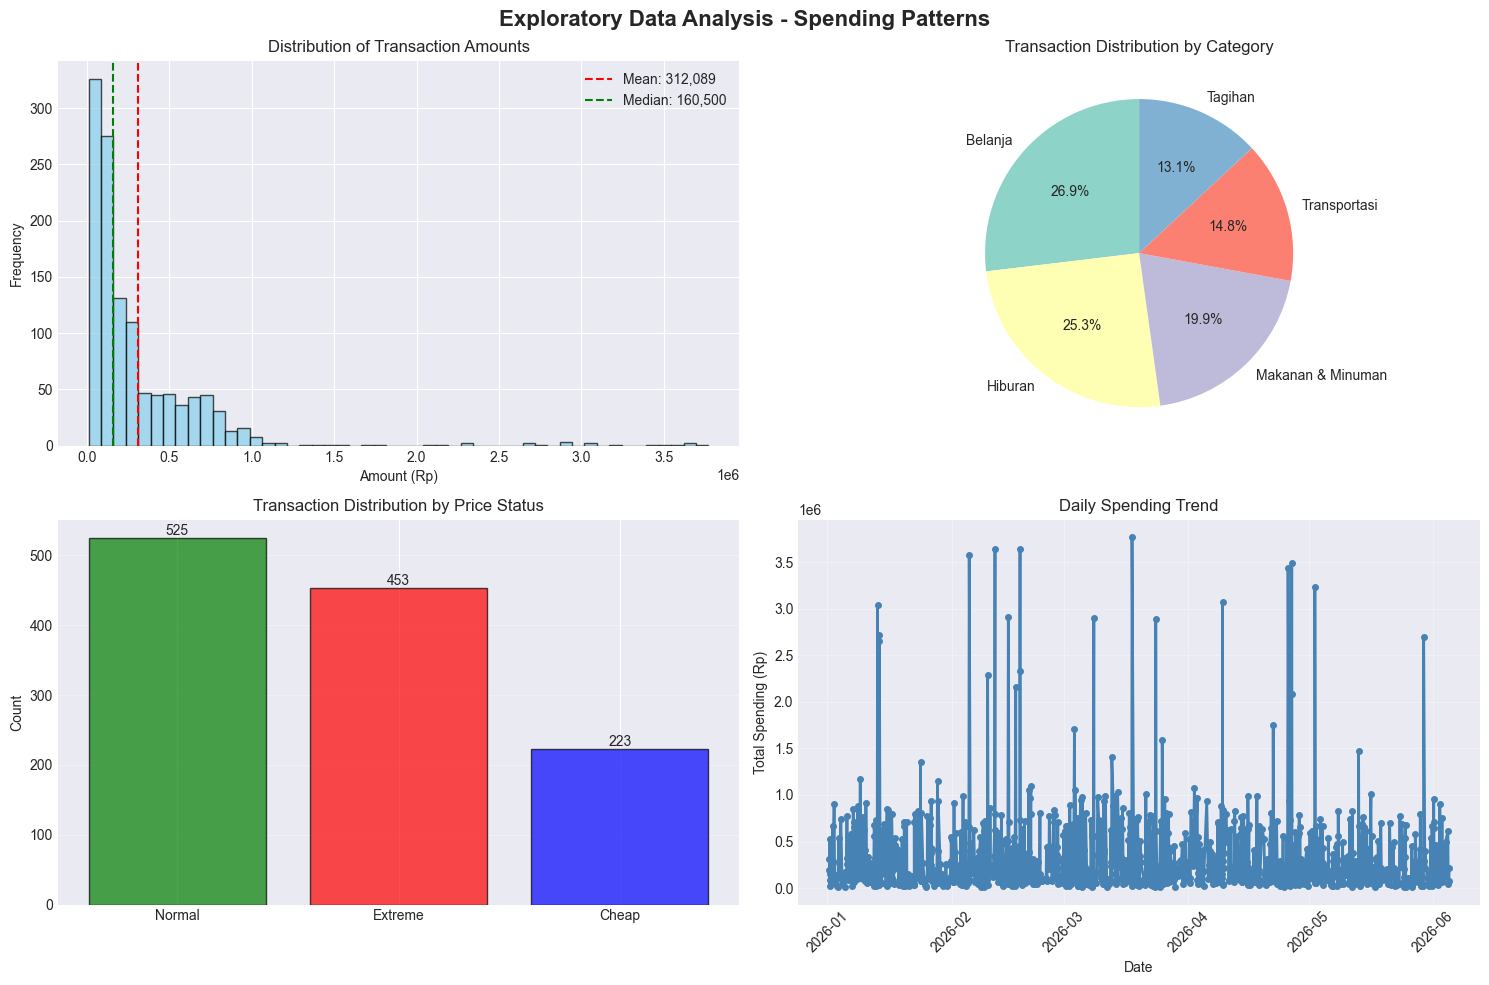

✅ Visualizations saved as 'eda_analysis.png'


In [12]:
print("="*80)
print("📊 EDA - VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Exploratory Data Analysis - Spending Patterns', fontsize=16, fontweight='bold')

# 1. Distribution of amounts
axes[0, 0].hist(df['amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Amount (Rp)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Transaction Amounts')
axes[0, 0].axvline(df['amount'].mean(), color='red', linestyle='--', label=f"Mean: {df['amount'].mean():,.0f}")
axes[0, 0].axvline(df['amount'].median(), color='green', linestyle='--', label=f"Median: {df['amount'].median():,.0f}")
axes[0, 0].legend()

# 2. Category breakdown
category_counts = df['category'].value_counts()
colors = plt.cm.Set3(range(len(category_counts)))
axes[0, 1].pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 1].set_title('Transaction Distribution by Category')

# 3. Price Status distribution
status_counts = df['price_status'].value_counts()
colors_status = {'Normal': 'green', 'Cheap': 'blue', 'Extreme': 'red', 'Unknown': 'gray'}
bars = axes[1, 0].bar(status_counts.index, status_counts.values, 
                       color=[colors_status.get(x, 'gray') for x in status_counts.index],
                       alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Transaction Distribution by Price Status')
axes[1, 0].grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom')

# 4. Daily spending trend
daily_summary = df.groupby('transaction_date')['amount'].agg(['sum', 'count'])
axes[1, 1].plot(daily_summary.index, daily_summary['sum'], marker='o', color='steelblue', linewidth=2, markersize=4)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Total Spending (Rp)')
axes[1, 1].set_title('Daily Spending Trend')
axes[1, 1].grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Visualizations saved as 'eda_analysis.png'")

# 🎯 SEL 9: FEATURE SELECTION - SELEKSI KOLOM PENTING

### 🎯 Fungsi Utama
Memilih kolom yang paling penting untuk dashboard:
- Drop redundant columns
- Keep essential features
- Optimize for performance

In [13]:
print("="*80)
print("🎯 TAHAP 6: FEATURE SELECTION - SELEKSI KOLOM PENTING")
print("="*80)

print(f"\n1️⃣  Current Columns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    missing = df[col].isnull().sum()
    print(f"   {i:2d}. {col:30s} | Type: {str(dtype):15s} | Missing: {missing}")

print(f"\n2️⃣  Defining Essential Columns...")

# Essential columns untuk dashboard
essential_cols = {
    'Transaction Data': ['transaction_name', 'clean_name', 'amount', 'transaction_date'],
    'Temporal Features': ['year', 'month', 'day', 'week', 'day_of_week', 'month_name', 'is_weekend'],
    'Amount Features': ['amount_category', 'amount_quartile'],
    'Benchmark Data': ['matched_item', 'category', 'avg_price', 'lower_bound', 'upper_bound'],
    'Analysis Features': ['price_status', 'match_confidence', 'deviation_from_daily_avg']
}

# Flatten essential cols
all_essential = []
for group, cols in essential_cols.items():
    all_essential.extend(cols)
    print(f"\n   {group}:")
    for col in cols:
        if col in df.columns:
            print(f"      ✅ {col}")
        else:
            print(f"      ❌ {col} (NOT FOUND)")

print(f"\n3️⃣  Removing Redundant Columns...")

# Columns to drop (redundant atau intermediate)
cols_to_drop = [col for col in df.columns if col not in all_essential]

if cols_to_drop:
    print(f"   Dropping {len(cols_to_drop)} redundant columns:")
    for col in cols_to_drop:
        if col in df.columns:
            print(f"      - {col}")
    
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
else:
    print(f"   ✅ No redundant columns found")

print(f"\n4️⃣  Final Column Selection:")
print(f"   Total columns: {len(df_transactions.columns)} → {len(df.columns)}")
print(f"   Reduction: {len(df_transactions.columns) - len(df.columns)} columns removed")
print(f"\n   ✅ FINAL COLUMNS ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"      {i:2d}. {col}")

print(f"\n5️⃣  Data Shape After Feature Selection:")
print(f"   Shape: {df.shape}")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

🎯 TAHAP 6: FEATURE SELECTION - SELEKSI KOLOM PENTING

1️⃣  Current Columns (23):
    1. transaction_name               | Type: str             | Missing: 0
    2. amount                         | Type: float64         | Missing: 0
    3. category_encoded               | Type: int64           | Missing: 0
    4. clean_name                     | Type: str             | Missing: 0
    5. transaction_date               | Type: datetime64[s]   | Missing: 0
    6. year                           | Type: int32           | Missing: 0
    7. month                          | Type: int32           | Missing: 0
    8. day                            | Type: int32           | Missing: 0
    9. week                           | Type: UInt32          | Missing: 0
   10. day_of_week                    | Type: str             | Missing: 0
   11. is_weekend                     | Type: int64           | Missing: 0
   12. month_name                     | Type: str             | Missing: 0
   13. year_month  

# 💾 SEL 10: FINAL OUTPUT - EXPORT DATA BERSIH

### 🎯 Fungsi Utama
Menyimpan data final yang sudah melalui seluruh pipeline processing:
- Save ke CSV
- Data Quality Report
- Summary Statistics

In [14]:
print("="*80)
print("💾 TAHAP 7: FINAL OUTPUT - EXPORT DATA BERSIH")
print("="*80)

print(f"\n1️⃣  Sorting Data...")

# Sort by date
df = df.sort_values('transaction_date').reset_index(drop=True)
print(f"   ✅ Data sorted by transaction_date")

print(f"\n2️⃣  Final Data Quality Check...")

# Final validation
missing_final = df.isnull().sum()
missing_pct_final = (missing_final / len(df)) * 100

critical_missing = 0
for col in ['transaction_date', 'amount', 'clean_name']:
    if col in df.columns and missing_final[col] > 0:
        print(f"   ⚠️  {col}: {missing_final[col]} missing")
        critical_missing += missing_final[col]

if critical_missing == 0:
    print(f"   ✅ No critical missing values in essential columns")

print(f"\n3️⃣  Saving Data to CSV...")

# Define output path
output_path = Path('.').resolve() / 'main_dashboard_dataset.csv'

try:
    df.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"   ✅ Successfully saved to: {output_path}")
    print(f"   📊 File size: {output_path.stat().st_size / 1024:.2f} KB")
except Exception as e:
    print(f"   ❌ Error saving file: {e}")
    print(f"   💡 Make sure the file is not open in Excel or another program")

print(f"\n4️⃣  Generating Final Report...")

report = {
    'Processing Summary': {
        'Total Records': len(df),
        'Total Columns': len(df.columns),
        'Date Range': f"{df['transaction_date'].min().date()} to {df['transaction_date'].max().date()}",
        'Total Spending': f"Rp {df['amount'].sum():,.0f}",
        'Average Spending': f"Rp {df['amount'].mean():,.0f}",
        'Data Completeness': f"{(100 - (missing_final.sum() / (len(df) * len(df.columns)) * 100)):.2f}%"
    },
    'Category Breakdown': df['category'].value_counts().to_dict(),
    'Price Status': df['price_status'].value_counts().to_dict(),
    'Match Confidence': df['match_confidence'].value_counts().to_dict()
}

print(f"\n   ┌─ PROCESSING SUMMARY")
for key, value in report['Processing Summary'].items():
    print(f"   ├─ {key:20s}: {value}")

print(f"\n   ┌─ CATEGORY BREAKDOWN")
for category, count in report['Category Breakdown'].items():
    pct = (count / len(df)) * 100
    print(f"   ├─ {category:20s}: {count:4d} ({pct:5.1f}%)")

print(f"\n   ┌─ PRICE STATUS")
for status, count in report['Price Status'].items():
    pct = (count / len(df)) * 100
    print(f"   ├─ {status:20s}: {count:4d} ({pct:5.1f}%)")

print(f"\n   ┌─ MATCH CONFIDENCE")
for confidence, count in report['Match Confidence'].items():
    pct = (count / len(df)) * 100
    print(f"   ├─ {confidence:20s}: {count:4d} ({pct:5.1f}%)")

print(f"\n\n✅ PIPELINE PROCESSING COMPLETED SUCCESSFULLY!")
print(f"\n📊 Data Ready for Dashboard: {output_path.name}")

💾 TAHAP 7: FINAL OUTPUT - EXPORT DATA BERSIH

1️⃣  Sorting Data...
   ✅ Data sorted by transaction_date

2️⃣  Final Data Quality Check...
   ✅ No critical missing values in essential columns

3️⃣  Saving Data to CSV...
   ✅ Successfully saved to: G:\Semester4\capstone-project\main_dashboard_dataset.csv
   📊 File size: 238.15 KB

4️⃣  Generating Final Report...

   ┌─ PROCESSING SUMMARY
   ├─ Total Records       : 1201
   ├─ Total Columns       : 21
   ├─ Date Range          : 2026-01-01 to 2026-06-04
   ├─ Total Spending      : Rp 374,818,490
   ├─ Average Spending    : Rp 312,089
   ├─ Data Completeness   : 100.00%

   ┌─ CATEGORY BREAKDOWN
   ├─ Belanja             :  323 ( 26.9%)
   ├─ Hiburan             :  304 ( 25.3%)
   ├─ Makanan & Minuman   :  239 ( 19.9%)
   ├─ Transportasi        :  178 ( 14.8%)
   ├─ Tagihan             :  157 ( 13.1%)

   ┌─ PRICE STATUS
   ├─ Normal              :  525 ( 43.7%)
   ├─ Extreme             :  453 ( 37.7%)
   ├─ Cheap               :  223 ( 1

# 👁️ SEL 11: PREVIEW & VERIFICATION - PEMERIKSAAN FINAL

### 🎯 Fungsi Utama
Verifikasi output final dan lihat preview data

In [15]:
print("="*80)
print("👁️  FINAL PREVIEW & VERIFICATION")
print("="*80)

print(f"\n1️⃣  First 10 Rows:")
display(df.head(10))

print(f"\n2️⃣  Last 10 Rows:")
display(df.tail(10))

print(f"\n3️⃣  Data Info:")
print(f"   Columns: {df.columns.tolist()}")
print(f"   Dtypes:\n")
print(df.dtypes)

print(f"\n4️⃣  Random Samples (5 random rows):")
display(df.sample(min(5, len(df))))

print(f"\n✅ Data Processing Pipeline Completed Successfully!")
print(f"\n📌 Next Steps:")
print(f"   1. Load this clean data into Streamlit dashboard")
print(f"   2. Use columns: {', '.join(df.columns[:5])}... for visualization")
print(f"   3. Filter by: category, price_status, transaction_date")
print(f"   4. Group by: month_name, day_of_week, category for analysis")

👁️  FINAL PREVIEW & VERIFICATION

1️⃣  First 10 Rows:


,transaction_name,amount,clean_name,transaction_date,year,month,day,week,day_of_week,is_weekend,month_name,amount_quartile,amount_category,deviation_from_daily_avg,matched_item,category,avg_price,lower_bound,upper_bound,match_confidence,price_status
0,TAGIHAN AIR PDAM - <ID>,314500.0,TAGIHAN AIR PDAM,2026-01-01 10:55:53,2026,1,1,1,Thursday,0,January,Q3,Besar (100K-500K),132450.0,tagihan gas pgn,Tagihan,75000.0,40000.0,150000.0,Matched,Extreme
1,PEMBAYARAN LISTRIK PLN - <ID>,198250.0,PEMBAYARAN LISTRIK PLN,2026-01-01 12:06:25,2026,1,1,1,Thursday,0,January,Q3,Besar (100K-500K),16200.0,pembayaran sks semester pendek,Tagihan,300000.0,150000.0,500000.0,Matched,Cheap
2,BELANJA ELEKTRONIK*MEMO - <ID>,523000.0,BELANJA ELEKTRONIK,2026-01-01 13:36:24,2026,1,1,1,Thursday,0,January,Q4,Sangat Besar (>500K),340950.0,belanja elektronik,Belanja,500000.0,100000.0,2000000.0,Matched,Normal
3,TIKET KERETA KAI - <ID>,22200.0,TIKET KERETA KAI,2026-01-01 13:38:35,2026,1,1,1,Thursday,0,January,Q1,Kecil (<50K),-159850.0,tiket kereta lokal,Transportasi,10000.0,3000.0,25000.0,Matched,Normal
4,SH0P33P4Y*PR0M0 - <ID>,155000.0,SH0P33P4Y*PR0M0,2026-01-01 16:58:07,2026,1,1,1,Thursday,0,January,Q2,Besar (100K-500K),-27050.0,spotify premium,Hiburan,55000.0,25000.0,87000.0,Matched,Normal
5,MIE GACOAN REST - <ID>,84250.0,MIE GACOAN REST,2026-01-01 17:52:03,2026,1,1,1,Thursday,0,January,Q2,Sedang (50-100K),-97800.0,mie gacoan,Makanan & Minuman,25000.0,10000.0,50000.0,Matched,Normal
6,GO-FOOD TRANSAKSI - <ID>,65100.0,GO-FOOD TRANSAKSI,2026-01-01 18:47:41,2026,1,1,1,Thursday,0,January,Q1,Sedang (50-100K),-116950.0,gofood,Makanan & Minuman,50000.0,25000.0,100000.0,Matched,Normal
7,DBT TIKET BUS DAMRI - <ID>,76250.0,DBT TIKET BUS DAMRI,2026-01-01 18:55:48,2026,1,1,1,Thursday,0,January,Q1,Sedang (50-100K),-105800.0,tiket bus damri,Transportasi,50000.0,30000.0,150000.0,Matched,Normal
8,TIKET BIOSKOP XXI - <ID>,259000.0,TIKET BIOSKOP XXI,2026-01-01 19:37:20,2026,1,1,1,Thursday,0,January,Q3,Besar (100K-500K),76950.0,tiket bioskop,Hiburan,50000.0,35000.0,75000.0,Matched,Extreme
9,TIKET BIOSKOP XXI - <ID>,166000.0,TIKET BIOSKOP XXI,2026-01-01 19:48:15,2026,1,1,1,Thursday,0,January,Q3,Besar (100K-500K),-16050.0,tiket bioskop,Hiburan,50000.0,35000.0,75000.0,Matched,Normal



2️⃣  Last 10 Rows:


,transaction_name,amount,clean_name,transaction_date,year,month,day,week,day_of_week,is_weekend,month_name,amount_quartile,amount_category,deviation_from_daily_avg,matched_item,category,avg_price,lower_bound,upper_bound,match_confidence,price_status
1191,ISI PULSA TELKOMSEL - <ID>,437340.0,ISI PULSA TELKOMSEL,2026-06-03 14:12:01,2026,6,3,23,Wednesday,0,June,Q4,Besar (100K-500K),135632.727273,kuota internet telkomsel,Belanja,75000.0,45000.0,150000.0,Matched,Extreme
1192,TOKOPEDIA*MEMO - <ID>,281000.0,TOKOPEDIA,2026-06-03 17:14:48,2026,6,3,23,Wednesday,0,June,Q3,Besar (100K-500K),-20707.272727,tokopedia,Belanja,150000.0,50000.0,300000.0,Matched,Normal
1193,TIKET BIOSKOP XXI - <ID>,253080.0,TIKET BIOSKOP XXI,2026-06-03 17:56:55,2026,6,3,23,Wednesday,0,June,Q3,Besar (100K-500K),-48627.272727,tiket bioskop,Hiburan,50000.0,35000.0,75000.0,Matched,Extreme
1194,INDIHOME INTERNET - <ID>,185900.0,INDIHOME INTERNET,2026-06-03 21:59:32,2026,6,3,23,Wednesday,0,June,Q3,Besar (100K-500K),-115807.272727,kuota internet xl,Belanja,60000.0,40000.0,120000.0,Matched,Extreme
1195,BELANJA FASHION*MEMO - <ID>,126750.0,BELANJA FASHION,2026-06-04 02:00:15,2026,6,4,23,Thursday,0,June,Q2,Besar (100K-500K),-135398.333333,belanja fashion,Belanja,200000.0,50000.0,500000.0,Matched,Cheap
1196,PEMBAYARAN LISTRIK PLN - <ID>,498390.0,PEMBAYARAN LISTRIK PLN,2026-06-04 02:38:12,2026,6,4,23,Thursday,0,June,Q4,Besar (100K-500K),236241.666667,pembayaran sks semester pendek,Tagihan,300000.0,150000.0,500000.0,Matched,Normal
1197,INDIHOME INTERNET - <ID>,611000.0,INDIHOME INTERNET,2026-06-04 16:19:46,2026,6,4,23,Thursday,0,June,Q4,Sangat Besar (>500K),348851.666667,kuota internet xl,Belanja,60000.0,40000.0,120000.0,Matched,Extreme
1198,MCDONALDS MEAL PAYMENT - <ID>,42000.0,MCDONALDS MEAL PAYMENT,2026-06-04 18:12:52,2026,6,4,23,Thursday,0,June,Q1,Kecil (<50K),-220148.333333,mcdonalds,Makanan & Minuman,60000.0,30000.0,100000.0,Matched,Cheap
1199,TRF-V DISNEY HOTSTAR*MEMO - <ID>,219000.0,TRF-V DISNEY HOTSTAR,2026-06-04 23:00:09,2026,6,4,23,Thursday,0,June,Q3,Besar (100K-500K),-43148.333333,disney hotstar,Hiburan,39000.0,20000.0,65000.0,Matched,Extreme
1200,MCDONALDS MEAL PAYMENT - <ID>,75750.0,MCDONALDS MEAL PAYMENT,2026-06-04 23:06:41,2026,6,4,23,Thursday,0,June,Q1,Sedang (50-100K),-186398.333333,mcdonalds,Makanan & Minuman,60000.0,30000.0,100000.0,Matched,Normal



3️⃣  Data Info:
   Columns: ['transaction_name', 'amount', 'clean_name', 'transaction_date', 'year', 'month', 'day', 'week', 'day_of_week', 'is_weekend', 'month_name', 'amount_quartile', 'amount_category', 'deviation_from_daily_avg', 'matched_item', 'category', 'avg_price', 'lower_bound', 'upper_bound', 'match_confidence', 'price_status']
   Dtypes:

transaction_name                      str
amount                            float64
clean_name                            str
transaction_date            datetime64[s]
year                                int32
month                               int32
day                                 int32
week                               UInt32
day_of_week                           str
is_weekend                          int64
month_name                            str
amount_quartile                  category
amount_category                       str
deviation_from_daily_avg          float64
matched_item                          str
category        

,transaction_name,amount,clean_name,transaction_date,year,month,day,week,day_of_week,is_weekend,month_name,amount_quartile,amount_category,deviation_from_daily_avg,matched_item,category,avg_price,lower_bound,upper_bound,match_confidence,price_status
291,INDIHOME INTERNET - <ID>,553000.0,INDIHOME INTERNET,2026-02-08 03:33:10,2026,2,8,6,Sunday,1,February,Q4,Sangat Besar (>500K),297320.833333,kuota internet xl,Belanja,60000.0,40000.0,120000.0,Matched,Extreme
997,NETFLIX*SUBSCRIPTION - <ID>,197000.0,NETFLIX,2026-05-09 01:57:06,2026,5,9,19,Saturday,1,May,Q3,Besar (100K-500K),10166.250000,netflix,Hiburan,59000.0,54000.0,65000.0,Matched,Extreme
338,PEMBAYARAN LISTRIK PLN - <ID>,780900.0,PEMBAYARAN LISTRIK PLN,2026-02-13 08:56:29,2026,2,13,7,Friday,0,February,Q4,Sangat Besar (>500K),533336.363636,pembayaran sks semester pendek,Tagihan,300000.0,150000.0,500000.0,Matched,Extreme
432,INDIHOME INTERNET - <ID>,451000.0,INDIHOME INTERNET,2026-02-25 06:09:43,2026,2,25,9,Wednesday,0,February,Q4,Besar (100K-500K),64752.000000,kuota internet xl,Belanja,60000.0,40000.0,120000.0,Matched,Extreme
479,BOOKING HOTEL TRAVELOKA - <ID>,17750.0,BOOKING HOTEL TRAVELOKA,2026-03-02 03:27:47,2026,3,2,10,Monday,0,March,Q1,Kecil (<50K),-189620.909091,destinasi traveloka,Transportasi,500000.0,200000.0,1500000.0,Matched,Cheap



✅ Data Processing Pipeline Completed Successfully!

📌 Next Steps:
   1. Load this clean data into Streamlit dashboard
   2. Use columns: transaction_name, amount, clean_name, transaction_date, year... for visualization
   3. Filter by: category, price_status, transaction_date
   4. Group by: month_name, day_of_week, category for analysis
